# Test Phase Field
This notebook is to test the validity of the calculation based on phase field $\phi(x, y, z)$. 

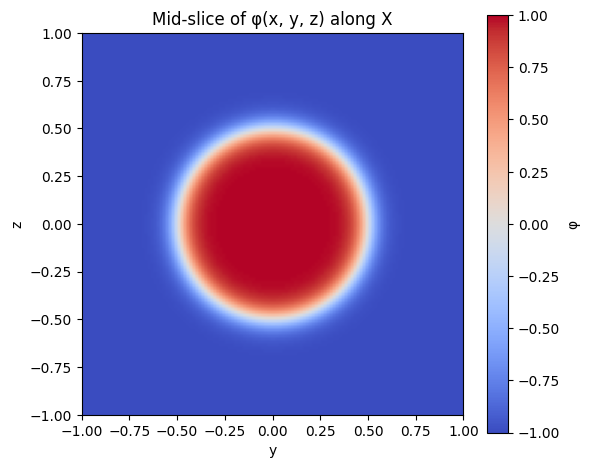

In [1]:
# Generation of the mock phase field and its visualization

from pinn.test_phase import generate_phase_field, visualize_phase_slice

radius = 0.5
epsilon = 0.05
grid_size = 128

phi, (x, y, z) = generate_phase_field(R=radius, epsilon=epsilon, grid_size=grid_size)
visualize_phase_slice(phi, x, y, z, axis='x')

In [16]:
# Calculate the volume and surface area of the sphere expressed by the phase field using fininte difference method (FDM)

from pinn.test_phase import compute_volume_fdm, compute_surface_area_fdm
import numpy as np

volume_fdm = compute_volume_fdm(phi, x, y, z)
area_fdm = compute_surface_area_fdm(phi, x, y, z, epsilon=epsilon)

print("Volume (true ) = ", 4*np.pi/3*radius**3)
print("Volume (phase) = ", volume_fdm)

print("Surface area (true ) = ", 4*np.pi*radius**2)
print("Surface area (phase) = ", area_fdm)

Volume (true ) =  0.5235987755982988
Volume (phase) =  0.549437311181059
Surface area (true ) =  3.141592653589793
Surface area (phase) =  3.1487338635359787


In [2]:
# Calculate the volume and surface area based on analytical representation of the field using autodiff

from pinn.test_phase import compute_volume_autodiff, compute_surface_area_autodiff, analytic_phi_fn
import jax

# Generate sample points in the cube [-1, 1]^3
N = 100000
key = jax.random.PRNGKey(0)
x_batch = jax.random.uniform(key, (N, 3), minval=-1.0, maxval=1.0)

phi_fn = lambda x: analytic_phi_fn(x, R=0.5, epsilon=0.05)
volume = compute_volume_autodiff(phi_fn, x_batch, V_box=8.0)
area = compute_surface_area_autodiff(phi_fn, x_batch, epsilon=0.05, V_box=8.0)

print("Volume (autodiff):", volume)
print("Surface area (autodiff):", area)


Volume (autodiff): 0.54876333
Surface area (autodiff): 3.1752183


In [ ]:
# # Train neural network so that it mimics the mock field function
from pinn.test_phase import train_neural_network, visualize_phi_slice_from_nn, save_checkpoint, plot_training_logs
import numpy as np

# state, model, training_logs = train_neural_network(learning_rate=1e-3, num_steps=7000, log_interval=100, alpha=0)
# state, model, training_logs = train_neural_network(learning_rate=1e-3, num_steps=7000, switch_first=3000, switch_second=5000, log_interval=100, alpha=0.01, beta=1e-7)
# state, model, training_logs = train_neural_network(learning_rate=1e-3, num_steps=10000, switch_first=5005, switch_second=5005, log_interval=100, alpha=0.01, beta=1e-7)

# state, model, training_logs = train_neural_network(learning_rate=1e-3, num_steps=10000, switch_first=1000, switch_second=2000, log_interval=1000, alpha=0.01, beta=1e-7)

state, model, training_logs = train_neural_network(learning_rate=1e-3, num_steps=1000, switch_first=1000, switch_second=2000, log_interval=100, alpha=0.01, beta=1e-6, restart_dir="../outputs/logs/test_phase/switch2-2/30000/default/")


# save_checkpoint(state)
# np.savez("logs_phasefield.npz", loss=loss, volume=volume, area=area)

phi_fn = lambda x: model.apply(state.params, x)

visualize_phi_slice_from_nn(phi_fn, grid_size=128, z_value=0.0)
plot_training_logs(training_logs)


# Convert training_logs (list of dicts) to a dict of lists
log_dict = {key: [entry[key] for entry in training_logs] for key in training_logs[0].keys()}
# Save to .npz file
np.savez("../outputs/logs/test_phase/training_logs.npz", **log_dict)



Starting from step 30000.


  0%|          | 0/1001 [00:00<?, ?it/s]

Step 30000/31000, Loss: 0.066453, Volume: 0.5464, Area: 3.0346


In [2]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')

import matplotlib
print(matplotlib.__file__)


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/matplotlib/__init__.py


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


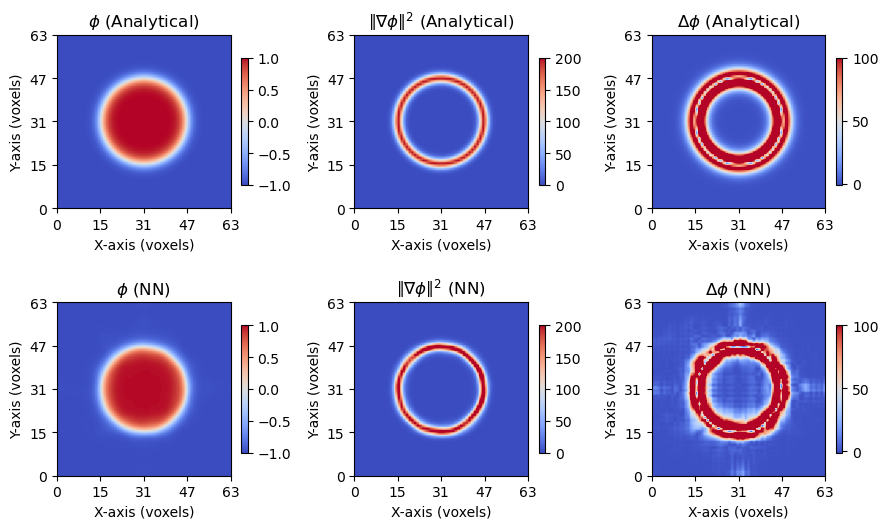

In [3]:
from pinn.plot import visualize_physics_loss
from pinn.test_phase import analytic_phi_fn
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.model import PINN

GRID_SIZE = 64
epsilon = 0.05

# Load checkpoint data
# checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/7000/default/")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/10000/default/")
checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/30500/default/")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/switch2-2/19600/default/")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/phi_only/7000/default/")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/switch_3000_001/7000/default/")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=None)

params = checkpoint_data["params"]
model = PINN()
phi_pinn = lambda x: model.apply(params, x)
phi_true = analytic_phi_fn

# Create a figure with horizontally arranged subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))


visualize_physics_loss(axes[0,0], phi_fn=phi_true, epsilon = epsilon, component = "phi", grid_size = GRID_SIZE, slice_index=32, axis="z", title="Analytical", vmin=-1, vmax=1)
axes[0,0].set_title(r"$\phi$ (Analytical)")
visualize_physics_loss(axes[0,1], phi_fn=phi_true, epsilon = epsilon, component = "grad_norm2", grid_size = GRID_SIZE, slice_index=32, axis="z", title="Analytical", vmin=0, vmax=2e2)
axes[0,1].set_title(r"$\left\|\nabla \phi \right\|^2$ (Analytical)")
visualize_physics_loss(axes[0,2], phi_fn=phi_true, epsilon = epsilon, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", title="Analytical", vmin=-1, vmax=100)
axes[0,2].set_title(r"$\Delta\phi$ (Analytical)")

visualize_physics_loss(axes[1,0], phi_fn=phi_pinn, epsilon = epsilon, component = "phi", grid_size = GRID_SIZE, slice_index=32, axis="z", title="NN", vmin=-1, vmax=1)
axes[1,0].set_title(r"$\phi$ (NN)")
visualize_physics_loss(axes[1,1], phi_fn=phi_pinn, epsilon = epsilon, component = "grad_norm2", grid_size = GRID_SIZE, slice_index=32, axis="z", title="NN", vmin=0, vmax=2e2)
axes[1,1].set_title(r"$\left\|\nabla \phi \right\|^2$ (NN)")
visualize_physics_loss(axes[1,2], phi_fn=phi_pinn, epsilon = epsilon, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", title="NN", vmin=-1, vmax=100)
axes[1,2].set_title(r"$\Delta\phi$ (NN)")

# Adjust layout and add colorbar
plt.tight_layout()
plt.savefig("../outputs/figs/phase_initial.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/switch2-2/10000/default/")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=None)
# params = checkpoint_data["params"]
opt_state = checkpoint_data["opt_state"]
print(opt_state)

{'0': {'count': Array(10000, dtype=int32), 'mu': {'params': {'Dense_0': {'bias': Array([-4.0454757e-05,  3.3427338e-04,  2.6211905e-04,  2.2261607e-04,
        7.9805602e-04,  1.4763212e-04, -2.1162794e-04, -3.5380389e-04,
       -5.0592306e-04, -1.2053501e-04,  1.9323081e-04,  4.0121257e-04,
        3.0242545e-05,  3.3954301e-04, -4.8949377e-04, -3.9074477e-04],      dtype=float32), 'kernel': Array([[ 5.1670604e-06,  1.4630993e-05, -3.1810781e-05, ...,
         3.8691949e-05, -7.6565768e-05, -4.9162159e-06],
       [-2.7212759e-06,  2.8574959e-08, -1.2902812e-05, ...,
        -6.0075221e-05,  2.8159309e-05, -3.7384762e-06],
       [-5.1289562e-06,  3.4766297e-05,  2.2793220e-06, ...,
        -5.2291256e-05, -5.7578531e-05, -3.7371428e-06],
       ...,
       [ 5.2280159e-04, -6.2018201e-02,  3.1645168e-02, ...,
        -8.1059314e-02,  9.5275246e-02,  7.0544705e-02],
       [-4.7045539e-04,  6.4769566e-02, -3.5248011e-02, ...,
         9.0555891e-02, -9.9334106e-02, -8.0465928e-02],
 

Array(1.0338961, dtype=float32)